**Proprocessing channels for inference**

In [1]:
import tifffile as tiff

nom_du_fichier = 'Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2'

# Charger l'image TIFF
image = tiff.imread(f"./preprocessing/raw_data/{nom_du_fichier}.tif")  # Assurez-vous que le fichier est bien au format TIFF

# Sélectionner les bons canaux 
channel_selectionnés = 'RGB'
image_selected = image[:, :, [5, 3, 1]]
print(image_selected.shape)

# Sauvegarder l'image avec les canaux sélectionnés
tiff.imwrite(f"{nom_du_fichier}_{channel_selectionnés}.tif", image_selected)

(8262, 12898, 3)


**Visualisation of segmentation**

In [ ]:
import rasterio
import numpy as np

# Ouvrir image de segmentation
with rasterio.open("inference/predictions/Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_RGB_seg.tif") as src:
    print(f"Dimensions: {src.shape}")  
    print(f"Nombre de bandes : {src.count}")
    segmentation = src.read(1)

# Statistiques de l’image
print(f"Min: {segmentation.min()}, Max: {segmentation.max()}, Moyenne: {segmentation.mean()}")

Dimensions: (8262, 12898)
Nombre de bandes : 1
Min: 0, Max: 1, Moyenne: 0.00033687965824173797


In [6]:
# Normaliser entre 0 et 255
segmentation_normalized = (segmentation - segmentation.min()) / (segmentation.max() - segmentation.min()) * 255
segmentation_normalized = segmentation_normalized.astype(np.uint8)

# Sauvegarder l'image normalisée
with rasterio.open("segmentation_fixed.tif", "w", driver="GTiff",
                   height=segmentation.shape[0], width=segmentation.shape[1],
                   count=1, dtype=segmentation_normalized.dtype) as dst:
    dst.write(segmentation_normalized, 1)

c:\Users\Chris\anaconda3\envs\GLO70302_p\lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


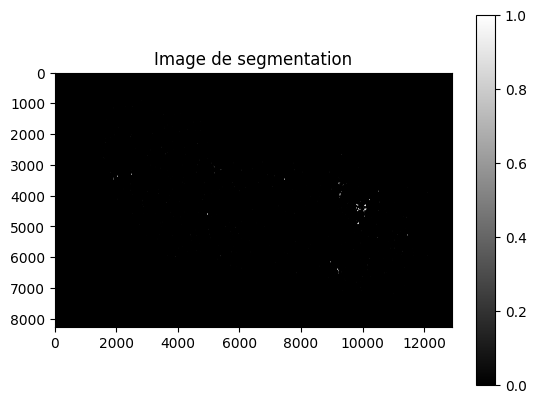

In [7]:
import matplotlib.pyplot as plt

plt.imshow(segmentation, cmap="gray")
plt.colorbar()
plt.title("Image de segmentation")
plt.show()